In [1]:
import pandas as pd
import numpy as np
import sklearn
from tqdm.auto import tqdm

In [2]:
PATH_TO_DATA = "data/solution_evaluation/clean/clean_v2.csv"

In [3]:
raw = pd.read_csv(PATH_TO_DATA)
raw.shape

(642, 28)

In [4]:
raw.head()

,sample_id,origin,augmentation_type,generation_basis,source_site,language,case_id,case_title,case_text,case_url,...,case_parser_mode,needs_review,retrieved_at,score_factchecking,score_originality,score_effectiveness,score_logic,score_completeness,score_total,evaluation_rationale
0,real_0001,real,NaN,human_published_solution,Executive.ru,ru,1982409,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,2026-08-27T18:20:04.710007+00:00,100.0,75.0,85.0,80.0,80.0,84.0,Ключевой ход: Если подрядчик виноват в сдвижен...
1,real_0002,real,NaN,human_published_solution,Executive.ru,ru,1982409,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,2026-08-27T18:20:04.710007+00:00,95.0,75.0,50.0,70.0,45.0,67.5,Ключевой ход: Либо при закупке оборудования ЦО...
2,real_0003,real,NaN,human_published_solution,Executive.ru,ru,1982409,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,2026-08-27T18:20:04.710007+00:00,95.0,70.0,75.0,80.0,85.0,80.0,"Ключевой ход: Наверное, мое решение не будет о..."
3,real_0004,real,NaN,human_published_solution,Executive.ru,ru,1982409,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,2026-08-27T18:20:04.710007+00:00,95.0,80.0,50.0,75.0,60.0,71.8,Ключевой ход: Что необходимо делать: - Тщатель...
4,real_0005,real,NaN,human_published_solution,Executive.ru,ru,1982409,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,2026-08-27T18:20:04.710007+00:00,95.0,85.0,60.0,70.0,60.0,74.8,Ключевой ход: Что он поставляет и от чего зави...


In [5]:
raw.loc[raw['augmentation_type'].isnull(), 'augmentation_type'] = 'original'

In [6]:
raw['augmentation_type'].value_counts()

augmentation_type
original             438
low_factchecking      34
low_originality       34
low_effectiveness     34
low_logic             34
low_completeness      34
very_weak             34
Name: count, dtype: int64

In [7]:
raw.loc[raw['augmentation_type']=='very_weak']

,sample_id,origin,augmentation_type,generation_basis,source_site,language,case_id,case_title,case_text,case_url,...,case_parser_mode,needs_review,retrieved_at,score_factchecking,score_originality,score_effectiveness,score_logic,score_completeness,score_total,evaluation_rationale
443,syn_1982409_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1982409,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,NaN,36.0,34.0,18.0,38.0,22.0,29.2,Ответ частично игнорирует прямой запрет на отк...
449,syn_1982400_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1982400,Прощаться или нет с CEO?,Дано: генеральный директор требует существенно...,https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,NaN,49.0,28.0,21.0,43.0,30.0,33.0,Ответ упрощает рынок руководителей и недооцени...
455,syn_1982394_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1982394,Как вернуть гостей в рестораны?,"Дано. Сеть ресторанов, работающая в сегменте «...",https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,NaN,41.0,51.0,17.0,44.0,26.0,35.7,"Некоторые маркетинговые идеи релевантны, но кл..."
461,syn_1982386_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1982386,"Как не подставиться, поручившись за работника ...","Корпоративный кредит – льгота, которую компани...",https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,NaN,20.0,25.0,7.0,36.0,22.0,20.7,Предлагаются юридически и этически проблемные ...
467,syn_1982379_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1982379,Как неизвестной компании выйти на федеральный ...,Стартовая ситуация\n\nНаша компания работает в...,https://www.e-xecutive.ru/education/cases/1982...,...,linked_page,False,NaN,45.0,42.0,25.0,49.0,28.0,37.3,Ответ поверхностный: не учитывает ограничения ...
473,syn_1979833_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1979833,Антикризисный план для музея,Executive.ru часто пишет о проблемах российско...,https://www.e-xecutive.ru/education/cases/1979...,...,catalog_slug_match,False,NaN,55.0,46.0,28.0,51.0,24.0,40.8,"Есть одна понятная маркетинговая идея, но она ..."
479,syn_1915529_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1915529,Справедливое наказание или имидж – чем пожертв...,Участник Сообщества Executive.ru Павел Кульгин...,https://www.e-xecutive.ru/education/cases/1915...,...,linked_page,False,NaN,43.0,31.0,22.0,52.0,29.0,34.0,Ответ фактически предлагает замять подтвержден...
485,syn_1839851_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1839851,"Как спасти от банкротства предприятие, которое...","Сообщество менеджеров Executive.ru, Международ...",https://www.e-xecutive.ru/education/cases/1839...,...,linked_page,False,NaN,38.0,45.0,16.0,44.0,24.0,33.0,"Социальная вовлеченность сама по себе полезна,..."
491,syn_1829328_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1829328,Волк в овечьей шкуре,Участница Сообщества Executive.ru Анастасия Ти...,https://www.e-xecutive.ru/education/cases/1829...,...,linked_page,False,NaN,35.0,26.0,18.0,43.0,25.0,28.2,Решение основано на субъективном впечатлении и...
497,syn_1776591_06,synthetic,very_weak,model_generated_from_case_text_only,model_generated_augmentation,ru,1776591,В погоне за двумя зайцами,Участник Сообщества Executive.ru Дмитрий Проск...,https://www.e-xecutive.ru/education/cases/1776...,...,linked_page,False,NaN,42.0,25.0,24.0,48.0,28.0,32.0,Ответ сводит сложную трансформацию к давлению ...


In [8]:
raw.columns

Index(['sample_id', 'origin', 'augmentation_type', 'generation_basis',
       'source_site', 'language', 'case_id', 'case_title', 'case_text',
       'case_url', 'solution_page_id', 'solution_page_url', 'solution_index',
       'solution_title', 'solution_author_raw', 'solution_text', 'is_winner',
       'parser_mode', 'case_parser_mode', 'needs_review', 'retrieved_at',
       'score_factchecking', 'score_originality', 'score_effectiveness',
       'score_logic', 'score_completeness', 'score_total',
       'evaluation_rationale'],
      dtype='object')

In [9]:
cols = ['case_id', 'is_winner', 'sample_id', 'origin', 'augmentation_type', 'case_title', 'case_text', 'solution_text', 'score_factchecking', 'score_originality', 'score_effectiveness', 'score_logic', 'score_completeness', 'score_total']

In [10]:
df = raw.copy()[cols]
df

,case_id,is_winner,sample_id,origin,augmentation_type,case_title,case_text,solution_text,score_factchecking,score_originality,score_effectiveness,score_logic,score_completeness,score_total
0,1982409,True,real_0001,real,original,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",Перед запуском любого проекта составляется так...,100.0,75.0,85.0,80.0,80.0,84.0
1,1982409,False,real_0002,real,original,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",Грамотный квалифицированный подрядчик должен н...,95.0,75.0,50.0,70.0,45.0,67.5
2,1982409,False,real_0003,real,original,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",В ситуации непонятны некоторые моменты: с одно...,95.0,70.0,75.0,80.0,85.0,80.0
3,1982409,False,real_0004,real,original,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",Главной базовой проблемой заказчика является н...,95.0,80.0,50.0,75.0,60.0,71.8
4,1982409,False,real_0005,real,original,Скачки напряжения испортили отношения с заказч...,"Дано: подрядчик строит ЦОД для заказчика, но н...",Вечная проблема: беда кроется в монополизме.\n...,95.0,85.0,60.0,70.0,60.0,74.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637,661498,False,syn_661498_02,synthetic,low_originality,Защита Дюжина,Executive.ru представляет новый кейс в рамках ...,Дюжину не стоит превращать заседание только в ...,95.0,40.0,85.0,91.0,87.0,77.0
638,661498,False,syn_661498_03,synthetic,low_effectiveness,Защита Дюжина,Executive.ru представляет новый кейс в рамках ...,"Чтобы гарантировать защиту, Дюжин может нанять...",83.0,74.0,20.0,67.0,78.0,61.9
639,661498,False,syn_661498_04,synthetic,low_logic,Защита Дюжина,Executive.ru представляет новый кейс в рамках ...,Дюжин должен показать совету абсолютную лояльн...,81.0,58.0,26.0,15.0,64.0,49.0
640,661498,False,syn_661498_05,synthetic,low_completeness,Защита Дюжина,Executive.ru представляет новый кейс в рамках ...,"Первое, что я бы сделал Дюжину, — подготовил о...",97.0,63.0,79.0,89.0,26.0,72.2


In [11]:
df.to_csv("data/solution_evaluation/clean/clean_v2_for_model.csv", index=False)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
import seaborn as sns
import matplotlib.pyplot as plt

## Распределение оценок по критериям

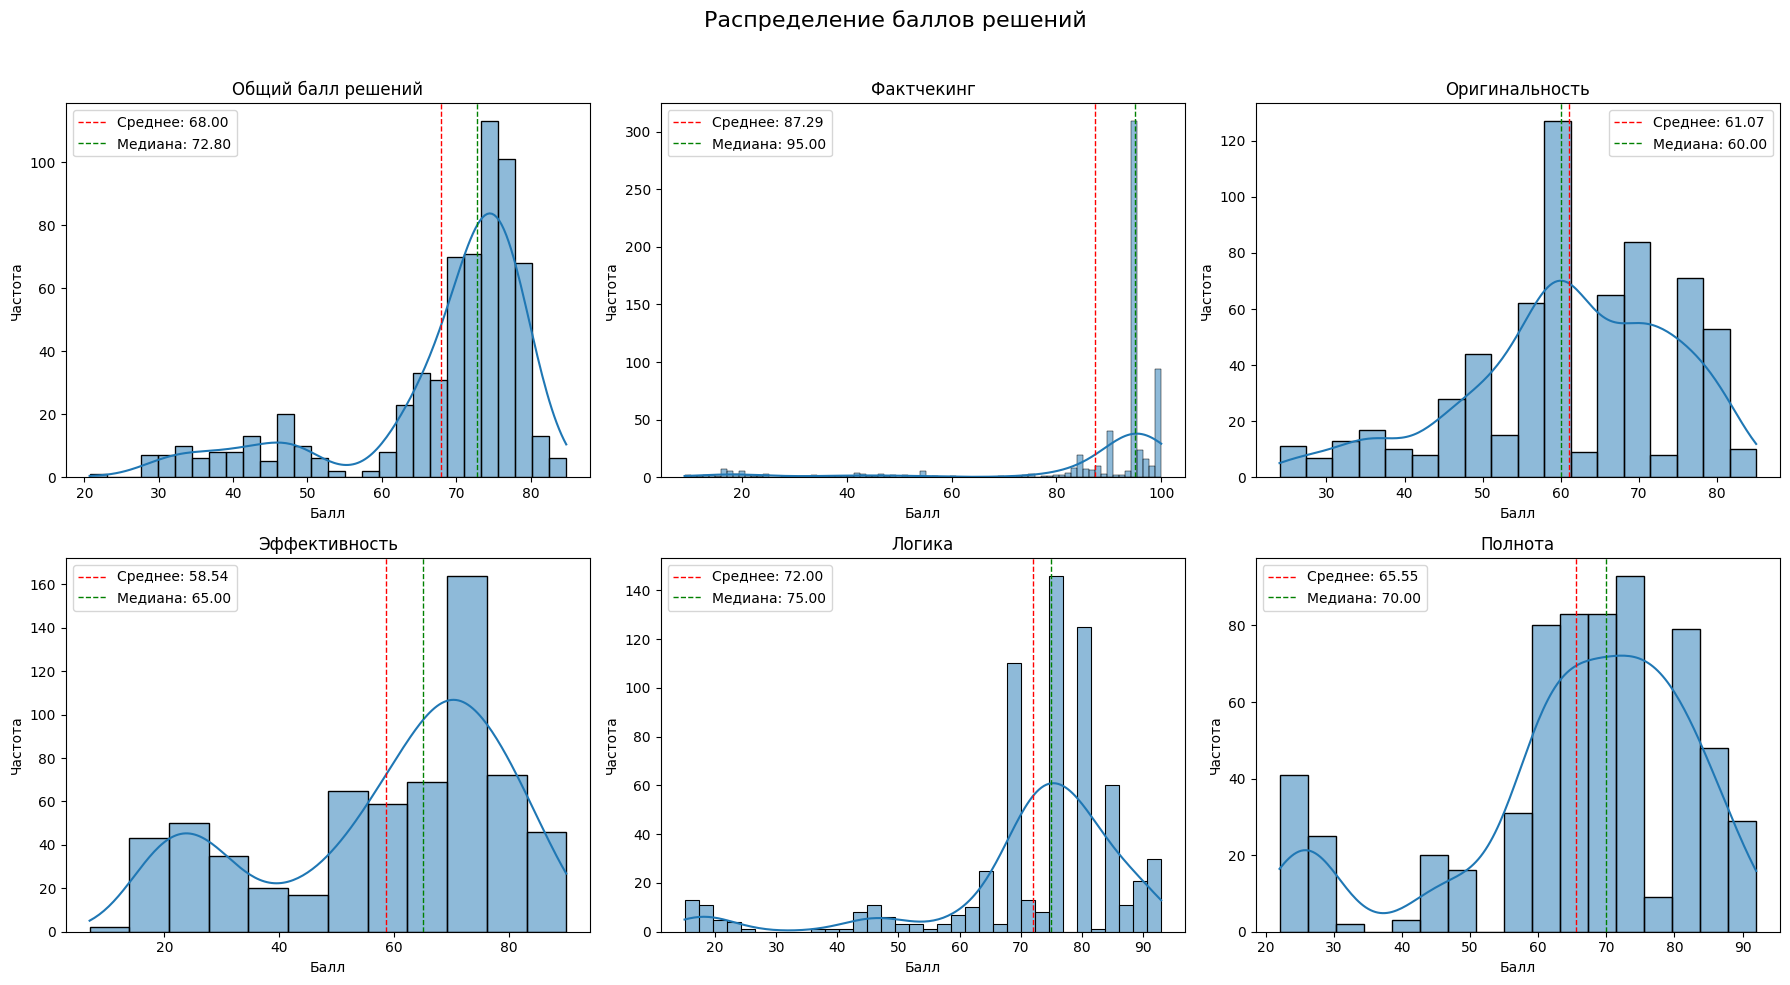

In [13]:
score_columns = {
    'score_total': 'Общий балл решений',
    'score_factchecking': 'Фактчекинг',
    'score_originality': 'Оригинальность',
    'score_effectiveness': 'Эффективность',
    'score_logic': 'Логика',
    'score_completeness': 'Полнота',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (column, title) in zip(axes.flat, score_columns.items()):
    sns.histplot(data=df, x=column, kde=True, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Балл")
    ax.set_ylabel("Частота")
    ax.axvline(df[column].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Среднее: {df[column].mean():.2f}')
    ax.axvline(df[column].median(), color='green', linestyle='dashed', linewidth=1, label=f'Медиана: {df[column].median():.2f}')
    ax.legend()

fig.suptitle("Распределение баллов решений", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [14]:
SCORES = score_columns.keys()

In [15]:
real = df.loc[df['origin'] == 'real'].copy()
real.shape

(438, 14)

In [16]:
MODEL_COLS = ['case_id', 'origin', 'augmentation_type', 'case_title', 'case_text', 'solution_text'] + list(SCORES)
real_df = real[MODEL_COLS].copy()
model_df = df[MODEL_COLS].copy()

Разбиение с `seed=1537` выполняется по `case_id`, поэтому решения одного кейса не попадают в разные выборки. Synthetic-решения для validation и test используются как отдельные стресс-наборы

In [17]:
SPLIT_SEED = 1537

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SPLIT_SEED)
trainval_idx, test_idx = next(gss_test.split(real_df, groups=real_df['case_id']))
trainval_df = real_df.iloc[trainval_idx].copy()
test_real = real_df.iloc[test_idx].copy()

gss_val = GroupShuffleSplit(n_splits=1, test_size=15 / 85, random_state=SPLIT_SEED + 1000)
train_idx, val_idx = next(gss_val.split(trainval_df, groups=trainval_df['case_id']))
train_real = trainval_df.iloc[train_idx].copy()
val_real = trainval_df.iloc[val_idx].copy()

In [18]:
train_case_ids = set(train_real['case_id'])
val_case_ids = set(val_real['case_id'])
test_case_ids = set(test_real['case_id'])

assert train_case_ids.isdisjoint(val_case_ids)
assert train_case_ids.isdisjoint(test_case_ids)
assert val_case_ids.isdisjoint(test_case_ids)

In [19]:
synthetic_df = df.loc[df['origin'].eq('synthetic')].copy()
train_synthetic = synthetic_df.loc[synthetic_df['case_id'].isin(train_case_ids)].copy()
stress_val = synthetic_df.loc[synthetic_df['case_id'].isin(val_case_ids)].copy()
stress_test = synthetic_df.loc[synthetic_df['case_id'].isin(test_case_ids)].copy()

assert set(train_synthetic['case_id']).isdisjoint(stress_val['case_id'])
assert set(train_synthetic['case_id']).isdisjoint(stress_test['case_id'])
assert set(stress_val['case_id']).isdisjoint(stress_test['case_id'])

{
    'train_real': train_real.shape,
    'train_synthetic': train_synthetic.shape,
    'val_real': val_real.shape,
    'stress_val': stress_val.shape,
    'test_real': test_real.shape,
    'stress_test': stress_test.shape,
}

{'train_real': (309, 12),
 'train_synthetic': (144, 14),
 'val_real': (67, 12),
 'stress_val': (18, 14),
 'test_real': (62, 12),
 'stress_test': (42, 14)}

In [20]:
train_all_synthetic = pd.concat([train_real, train_synthetic], ignore_index=True)

TARGETED_AUGMENTATION = {
    'score_factchecking': ['low_factchecking', 'very_weak'],
    'score_originality': ['low_originality', 'very_weak'],
    'score_effectiveness': ['low_effectiveness', 'very_weak'],
    'score_logic': ['low_logic', 'very_weak'],
    'score_completeness': ['low_completeness', 'very_weak'],
}

In [21]:
for name, part in [
    ("TRAIN REAL", train_real),
    ("VAL REAL", val_real),
    ("TEST REAL", test_real),
]:
    print("\n", name)
    print(part[SCORES].mean().round(1))


 TRAIN REAL
score_total            73.7
score_factchecking     95.5
score_originality      65.5
score_effectiveness    65.5
score_logic            76.1
score_completeness     69.3
dtype: float64

 VAL REAL
score_total            73.6
score_factchecking     94.7
score_originality      65.8
score_effectiveness    65.0
score_logic            76.5
score_completeness     69.6
dtype: float64

 TEST REAL
score_total            74.2
score_factchecking     95.2
score_originality      66.7
score_effectiveness    66.5
score_logic            75.7
score_completeness     69.7
dtype: float64


In [22]:
train_real.to_csv("data/solution_evaluation/model/train_real.csv", index=False)
train_all_synthetic.to_csv("data/solution_evaluation/model/train_real_synthetic.csv", index=False)
val_real.to_csv("data/solution_evaluation/model/val_real.csv", index=False)
stress_val.to_csv("data/solution_evaluation/model/stress_val.csv", index=False)
test_real.to_csv("data/solution_evaluation/model/test_real.csv", index=False)
stress_test.to_csv("data/solution_evaluation/model/stress_test.csv", index=False)

In [23]:
X_cols = ['case_title', 'case_text', 'solution_text']
Y_cols = list(SCORES)
Y_cols.remove('score_total')
TOTAL_SCORE_WEIGHTS = {
    'score_factchecking': 0.20,
    'score_originality': 0.25,
    'score_effectiveness': 0.25,
    'score_logic': 0.15,
    'score_completeness': 0.15,
}
TOTAL_WEIGHT_VECTOR = np.array([TOTAL_SCORE_WEIGHTS[column] for column in Y_cols])
BAD_THRESHOLD = 60
SELECTION_REAL_WEIGHT = 0.60
SELECTION_STRESS_WEIGHT = 0.40
SEARCH_ITERATIONS = 40
TEXT_REPRESENTATIONS = ['solution_only', 'combined', 'separate']

In [24]:
evaluation_sets = {
    'REAL_VAL': val_real,
    'STRESS_VAL': stress_val,
    'REAL_TEST': test_real,
    'STRESS_TEST': stress_test,
    'MIXED_TEST': pd.concat([test_real, stress_test], ignore_index=True),
}

y_train_real = train_real[Y_cols]
y_train_median = y_train_real.median()

## Медианный baseline

In [25]:
baseline_models = {
    target: float(y_train_median[target])
    for target in Y_cols
}
baseline_models

{'score_factchecking': 95.0,
 'score_originality': 65.0,
 'score_effectiveness': 70.0,
 'score_logic': 75.0,
 'score_completeness': 70.0}

## TF-IDF и Ridge по отдельным критериям

In [26]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline

In [88]:
def prepare_text_features(frame, representation):
    if representation == 'solution_only':
        return frame['solution_text'].fillna('')
    if representation == 'combined':
        return (
            'Заголовок кейса: ' + frame['case_title'].fillna('')
            + '\nОписание кейса: ' + frame['case_text'].fillna('')
            + '\nРешение: ' + frame['solution_text'].fillna('')
        )
    return frame[X_cols].fillna('')


def create_ridge_pipeline(representation):
    if representation == 'separate':
        features = ColumnTransformer(
            [
                ('case', TfidfVectorizer(), 'case_text'),
                ('solution', TfidfVectorizer(), 'solution_text'),
            ],
            transformer_weights={'case': 0.5, 'solution': 1.0},
        )
        return Pipeline([('features', features), ('ridge', Ridge(random_state=42))])
    return Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('ridge', Ridge(random_state=42)),
    ])


def predict_target_bundle(bundle, frame):
    predictions = pd.DataFrame(index=frame.index)
    for target, model_info in bundle.items():
        features = prepare_text_features(frame, model_info['representation'])
        predictions[target] = np.clip(model_info['model'].predict(features), 0, 100)
    predictions['score_total'] = (predictions[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR).round(1)
    return predictions

In [89]:
COMMON_RIDGE_PARAMS = {
    'ridge__alpha': np.logspace(-3, 3, 25),
    'ridge__fit_intercept': [True, False],
    'ridge__solver': ['lsqr', 'sparse_cg'],
    'ridge__tol': [1e-5, 1e-4, 1e-3, 1e-2],
}

SINGLE_TEXT_PARAMS = {
    'tfidf__analyzer': ['word', 'char_wb'],
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3), (2, 4), (3, 5)],
    'tfidf__max_features': [5000, 10000, 20000, 40000, None],
    'tfidf__min_df': [1, 2, 3, 5],
    'tfidf__max_df': [0.8, 0.9, 0.95, 1.0],
    'tfidf__sublinear_tf': [True, False],
    'tfidf__norm': ['l1', 'l2'],
    **COMMON_RIDGE_PARAMS,
}

SEPARATE_TEXT_PARAMS = {
    'features__case__ngram_range': [(1, 1), (1, 2)],
    'features__case__min_df': [1, 2, 3],
    'features__solution__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'features__solution__min_df': [1, 2, 3],
    'features__transformer_weights': [
        {'case': 0.25, 'solution': 1.0},
        {'case': 0.5, 'solution': 1.0},
        {'case': 0.75, 'solution': 1.0},
        {'case': 1.0, 'solution': 1.0},
    ],
    **COMMON_RIDGE_PARAMS,
}

SEARCH_SPACES = {
    'solution_only': SINGLE_TEXT_PARAMS,
    'combined': SINGLE_TEXT_PARAMS,
    'separate': SEPARATE_TEXT_PARAMS,
}

In [90]:
group_cv = GroupKFold(n_splits=4)
best_searches = {}
search_tasks = [(target, representation) for target in Y_cols for representation in TEXT_REPRESENTATIONS]

for target, representation in tqdm(search_tasks, desc='Подбор TF-IDF и Ridge'):
    search = RandomizedSearchCV(
        estimator=create_ridge_pipeline(representation),
        param_distributions=SEARCH_SPACES[representation],
        n_iter=SEARCH_ITERATIONS,
        scoring='neg_mean_absolute_error',
        cv=group_cv,
        n_jobs=1,
        random_state=42,
        refit=True,
        error_score='raise',
    )
    search.fit(
        prepare_text_features(train_real, representation),
        train_real[target],
        groups=train_real['case_id'],
    )
    best_searches[(target, representation)] = search

search_summary_df = pd.DataFrame([
    {
        'target': target,
        'representation': representation,
        'cv_mae': -search.best_score_,
        'best_params': search.best_params_,
    }
    for (target, representation), search in best_searches.items()
]).round({'cv_mae': 4})
search_summary_df

Подбор TF-IDF и Ridge:   0%|          | 0/15 [00:00<?, ?it/s]

,target,representation,cv_mae,best_params
0,score_factchecking,solution_only,1.8813,"{'tfidf__sublinear_tf': False, 'tfidf__norm': ..."
1,score_factchecking,combined,1.8337,"{'tfidf__sublinear_tf': False, 'tfidf__norm': ..."
2,score_factchecking,separate,1.9321,"{'ridge__tol': 0.01, 'ridge__solver': 'lsqr', ..."
3,score_originality,solution_only,6.5473,"{'tfidf__sublinear_tf': True, 'tfidf__norm': '..."
4,score_originality,combined,7.2738,"{'tfidf__sublinear_tf': True, 'tfidf__norm': '..."
5,score_originality,separate,7.1215,"{'ridge__tol': 0.001, 'ridge__solver': 'sparse..."
6,score_effectiveness,solution_only,5.6090,"{'tfidf__sublinear_tf': True, 'tfidf__norm': '..."
7,score_effectiveness,combined,7.2863,"{'tfidf__sublinear_tf': True, 'tfidf__norm': '..."
8,score_effectiveness,separate,6.5154,"{'ridge__tol': 0.0001, 'ridge__solver': 'spars..."
9,score_logic,solution_only,2.8892,"{'tfidf__sublinear_tf': True, 'tfidf__norm': '..."


## Сравнение режимов обучения

In [91]:
TRAINING_REGIMES = ['REAL_ONLY', 'ALL_SYNTH_WEIGHTED', 'TARGETED_SYNTH']
candidate_models = {}
fit_tasks = [
    (target, representation, regime)
    for target in Y_cols
    for representation in TEXT_REPRESENTATIONS
    for regime in TRAINING_REGIMES
]

for target, representation, regime in tqdm(fit_tasks, desc='Обучение отдельных Ridge'):
    if regime == 'REAL_ONLY':
        fit_frame = train_real
        sample_weights = None
    elif regime == 'ALL_SYNTH_WEIGHTED':
        fit_frame = train_all_synthetic
        sample_weights = np.where(fit_frame['origin'].eq('real'), 2.0, 1.0)
    else:
        targeted_synthetic = train_synthetic.loc[
            train_synthetic['augmentation_type'].isin(TARGETED_AUGMENTATION[target])
        ]
        fit_frame = pd.concat([train_real, targeted_synthetic], ignore_index=True)
        sample_weights = None

    model = clone(best_searches[(target, representation)].best_estimator_)
    fit_kwargs = {} if sample_weights is None else {'ridge__sample_weight': sample_weights}
    model.fit(
        prepare_text_features(fit_frame, representation),
        fit_frame[target],
        **fit_kwargs,
    )
    candidate_models[(target, representation, regime)] = {
        'model': model,
        'representation': representation,
        'training_regime': regime,
    }

validation_rows = []
for (target, representation, regime), model_info in tqdm(
    candidate_models.items(),
    total=len(candidate_models),
    desc='Real/stress validation',
):
    real_prediction = np.clip(
        model_info['model'].predict(prepare_text_features(val_real, representation)),
        0,
        100,
    )
    stress_prediction = np.clip(
        model_info['model'].predict(prepare_text_features(stress_val, representation)),
        0,
        100,
    )
    real_mae = mean_absolute_error(val_real[target], real_prediction)
    stress_mae = mean_absolute_error(stress_val[target], stress_prediction)
    validation_rows.append({
        'target': target,
        'representation': representation,
        'training_regime': regime,
        'real_val_mae': real_mae,
        'stress_val_mae': stress_mae,
        'selection_score': SELECTION_REAL_WEIGHT * real_mae + SELECTION_STRESS_WEIGHT * stress_mae,
    })

validation_df = pd.DataFrame(validation_rows).round(4)
selected_rows = validation_df.loc[
    validation_df.groupby('target')['selection_score'].idxmin()
].sort_values('target')
final_bundle = {}
for row in selected_rows.itertuples(index=False):
    final_bundle[row.target] = candidate_models[(row.target, row.representation, row.training_regime)]

selected_rows

Обучение отдельных Ridge:   0%|          | 0/45 [00:00<?, ?it/s]

Real/stress validation:   0%|          | 0/45 [00:00<?, ?it/s]

,target,representation,training_regime,real_val_mae,stress_val_mae,selection_score
37,score_completeness,solution_only,ALL_SYNTH_WEIGHTED,4.4643,10.8312,7.0111
19,score_effectiveness,solution_only,ALL_SYNTH_WEIGHTED,6.8556,15.4752,10.3035
7,score_factchecking,separate,ALL_SYNTH_WEIGHTED,4.5004,19.9932,10.6975
28,score_logic,solution_only,ALL_SYNTH_WEIGHTED,4.7452,9.6817,6.7198
10,score_originality,solution_only,ALL_SYNTH_WEIGHTED,6.6057,11.0158,8.3697


In [92]:
configuration_bundles = {}
for representation in TEXT_REPRESENTATIONS:
    for regime in TRAINING_REGIMES:
        bundle_name = f'RIDGE_{representation}_{regime}'
        configuration_bundles[bundle_name] = {
            target: candidate_models[(target, representation, regime)]
            for target in Y_cols
        }
configuration_bundles['RIDGE_FINAL_SELECTED'] = final_bundle

metric_rows = []
prediction_cache = {}
test_sets = {name: frame for name, frame in evaluation_sets.items() if name.endswith('TEST')}

for model_name, bundle in tqdm(
    configuration_bundles.items(),
    total=len(configuration_bundles),
    desc='Оценка Ridge на test-наборах',
):
    for dataset_name, frame in test_sets.items():
        predictions = predict_target_bundle(bundle, frame)
        prediction_cache[(model_name, dataset_name)] = predictions
        targets = frame[Y_cols].copy()
        targets['score_total'] = (targets[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR).round(1)
        true_bad = targets['score_total'] < BAD_THRESHOLD
        predicted_bad = predictions['score_total'] < BAD_THRESHOLD
        bad_recall = (true_bad & predicted_bad).sum() / true_bad.sum() if true_bad.sum() else np.nan

        for score_column in Y_cols + ['score_total']:
            metric_rows.append({
                'model': model_name,
                'dataset': dataset_name,
                'score': score_column,
                'MSE': mean_squared_error(targets[score_column], predictions[score_column]),
                'MAE': mean_absolute_error(targets[score_column], predictions[score_column]),
                'R2': r2_score(targets[score_column], predictions[score_column]),
                'bad_recall': bad_recall if score_column == 'score_total' else np.nan,
            })

for dataset_name, frame in test_sets.items():
    predictions = pd.DataFrame(
        np.tile(y_train_median.to_numpy(), (len(frame), 1)),
        columns=Y_cols,
        index=frame.index,
    )
    predictions['score_total'] = (predictions[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR).round(1)
    targets = frame[Y_cols].copy()
    targets['score_total'] = (targets[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR).round(1)
    true_bad = targets['score_total'] < BAD_THRESHOLD
    predicted_bad = predictions['score_total'] < BAD_THRESHOLD
    bad_recall = (true_bad & predicted_bad).sum() / true_bad.sum() if true_bad.sum() else np.nan
    for score_column in Y_cols + ['score_total']:
        metric_rows.append({
            'model': 'MEDIAN_REAL',
            'dataset': dataset_name,
            'score': score_column,
            'MSE': mean_squared_error(targets[score_column], predictions[score_column]),
            'MAE': mean_absolute_error(targets[score_column], predictions[score_column]),
            'R2': r2_score(targets[score_column], predictions[score_column]),
            'bad_recall': bad_recall if score_column == 'score_total' else np.nan,
        })

metrics_df = pd.DataFrame(metric_rows).round(4)
metrics_df

Оценка Ridge на test-наборах:   0%|          | 0/10 [00:00<?, ?it/s]

,model,dataset,score,MSE,MAE,R2,bad_recall
0,RIDGE_solution_only_REAL_ONLY,REAL_TEST,score_factchecking,17.2230,2.5140,0.0033,NaN
1,RIDGE_solution_only_REAL_ONLY,REAL_TEST,score_originality,71.1674,6.9975,0.2454,NaN
2,RIDGE_solution_only_REAL_ONLY,REAL_TEST,score_effectiveness,37.7678,5.1152,0.6468,NaN
3,RIDGE_solution_only_REAL_ONLY,REAL_TEST,score_logic,12.8047,2.8137,0.5014,NaN
4,RIDGE_solution_only_REAL_ONLY,REAL_TEST,score_completeness,14.8888,3.0696,0.8407,NaN
...,...,...,...,...,...,...,...
193,MEDIAN_REAL,MIXED_TEST,score_originality,218.5481,11.8558,-0.1105,NaN
194,MEDIAN_REAL,MIXED_TEST,score_effectiveness,715.0000,19.5385,-0.3280,NaN
195,MEDIAN_REAL,MIXED_TEST,score_logic,337.5865,11.2596,-0.0647,NaN
196,MEDIAN_REAL,MIXED_TEST,score_completeness,371.7692,13.8654,-0.0920,NaN


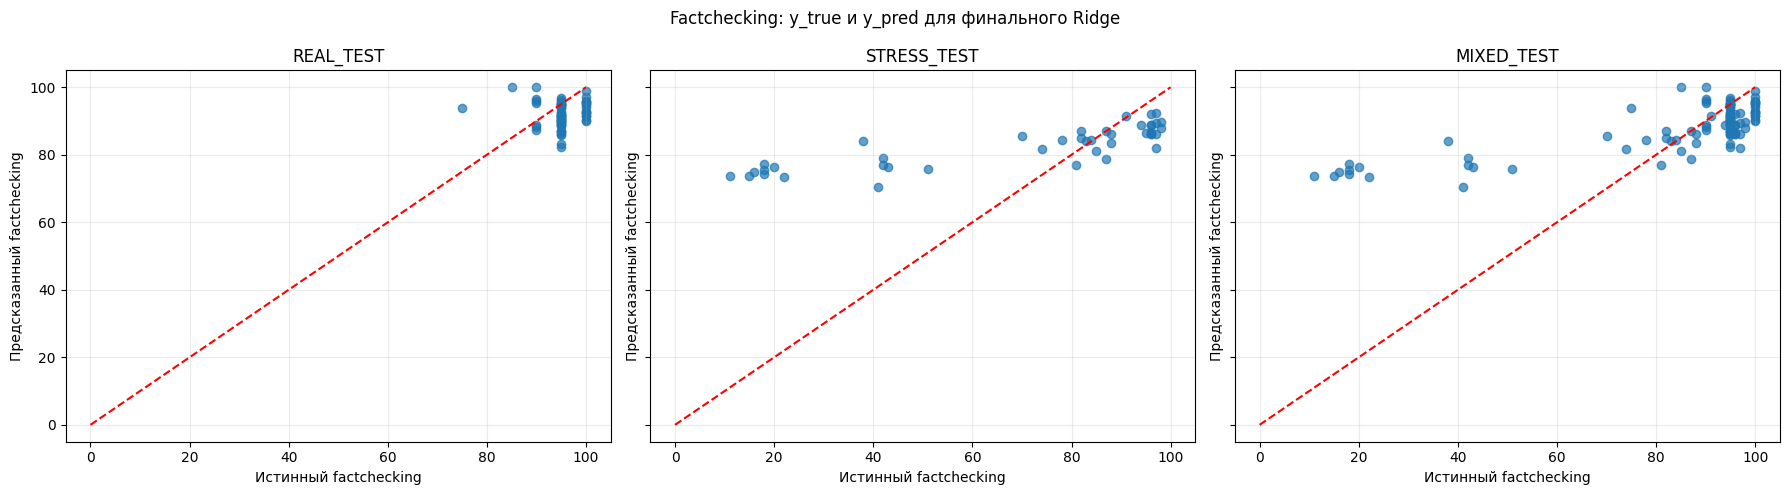

In [93]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
for ax, dataset_name in zip(axes, ['REAL_TEST', 'STRESS_TEST', 'MIXED_TEST']):
    frame = test_sets[dataset_name]
    predictions = prediction_cache[('RIDGE_FINAL_SELECTED', dataset_name)]
    ax.scatter(frame['score_factchecking'], predictions['score_factchecking'], alpha=0.7)
    ax.plot([0, 100], [0, 100], '--', color='red')
    ax.set_title(dataset_name)
    ax.set_xlabel('Истинный factchecking')
    ax.set_ylabel('Предсказанный factchecking')
    ax.grid(alpha=0.25)
fig.suptitle('Factchecking: y_true и y_pred для финального Ridge')
fig.tight_layout()
plt.show()

## Особенности оценки фактов

TF-IDF хорошо отражает структуру и полноту текста, но не проверяет утверждения по внешним источникам. Поэтому результат по factchecking рассматривается отдельно от остальных критериев

В большинстве критериев текст решения оказался полезнее объединения решения с условием кейса. Исключением стал factchecking, где раздельное представление условия и ответа дало лучший результат

## Сохранение моделей

In [94]:
from pathlib import Path

import joblib

ARTIFACTS_DIR = Path('../artifacts')
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

median_artifact = {
    'model_name': 'MEDIAN_REAL',
    'model_type': 'median_baseline',
    'median_scores': y_train_median.to_dict(),
    'target_columns': Y_cols,
    'total_score_weights': TOTAL_SCORE_WEIGHTS,
}

exported_models = {
    'MEDIAN_REAL': ARTIFACTS_DIR / 'evaluation_median_real.joblib',
}
joblib.dump(median_artifact, exported_models['MEDIAN_REAL'])

for model_name, bundle in tqdm(
    configuration_bundles.items(),
    total=len(configuration_bundles),
    desc='Экспорт моделей',
):
    artifact = {
        'model_name': model_name,
        'models': {target: model_info['model'] for target, model_info in bundle.items()},
        'representations': {
            target: model_info['representation']
            for target, model_info in bundle.items()
        },
        'training_regimes': {
            target: model_info['training_regime']
            for target, model_info in bundle.items()
        },
        'input_columns': X_cols,
        'target_columns': Y_cols,
        'total_score_weights': TOTAL_SCORE_WEIGHTS,
        'bad_threshold': BAD_THRESHOLD,
        'selection_weights': {'real': SELECTION_REAL_WEIGHT, 'stress': SELECTION_STRESS_WEIGHT},
    }
    artifact_path = ARTIFACTS_DIR / f'{model_name.lower()}.joblib'
    joblib.dump(artifact, artifact_path)
    exported_models[model_name] = artifact_path

search_summary_df.to_csv(ARTIFACTS_DIR / 'evaluation_ridge_search_summary.csv', index=False)
validation_df.to_csv(ARTIFACTS_DIR / 'evaluation_ridge_validation_metrics.csv', index=False)
metrics_df.to_csv(ARTIFACTS_DIR / 'evaluation_ridge_test_metrics.csv', index=False)

exported_models_df = pd.DataFrame([
    {'model': name, 'path': str(path.resolve())}
    for name, path in exported_models.items()
])
exported_models_df

Экспорт моделей:   0%|          | 0/10 [00:00<?, ?it/s]

,model,path
0,MEDIAN_REAL,C:\Users\Дарья\Documents\programming_projects\...
1,RIDGE_solution_only_REAL_ONLY,C:\Users\Дарья\Documents\programming_projects\...
2,RIDGE_solution_only_ALL_SYNTH_WEIGHTED,C:\Users\Дарья\Documents\programming_projects\...
3,RIDGE_solution_only_TARGETED_SYNTH,C:\Users\Дарья\Documents\programming_projects\...
4,RIDGE_combined_REAL_ONLY,C:\Users\Дарья\Documents\programming_projects\...
5,RIDGE_combined_ALL_SYNTH_WEIGHTED,C:\Users\Дарья\Documents\programming_projects\...
6,RIDGE_combined_TARGETED_SYNTH,C:\Users\Дарья\Documents\programming_projects\...
7,RIDGE_separate_REAL_ONLY,C:\Users\Дарья\Documents\programming_projects\...
8,RIDGE_separate_ALL_SYNTH_WEIGHTED,C:\Users\Дарья\Documents\programming_projects\...
9,RIDGE_separate_TARGETED_SYNTH,C:\Users\Дарья\Documents\programming_projects\...


# Итоговая модель TF-IDF + Ridge

Для всех пяти критериев используются реальные и синтетические решения с весами 2:1. Для фактчекинга выбрано раздельное представление условия и ответа, для остальных критериев только текст решения.

In [ ]:
FINAL_REPRESENTATIONS = {
    'score_factchecking': 'separate',
    'score_originality': 'solution_only',
    'score_effectiveness': 'solution_only',
    'score_logic': 'solution_only',
    'score_completeness': 'solution_only',
}
assert SPLIT_SEED == 1537
assert {target: final_bundle[target]['representation'] for target in Y_cols} == FINAL_REPRESENTATIONS
assert {final_bundle[target]['training_regime'] for target in Y_cols} == {'ALL_SYNTH_WEIGHTED'}
assert set(train_real['case_id']).isdisjoint(val_real['case_id'])
assert set(train_real['case_id']).isdisjoint(test_real['case_id'])
assert set(val_real['case_id']).isdisjoint(test_real['case_id'])

## Подбор параметров пяти моделей

In [ ]:
final_tuned_searches = {}
final_sample_weights = np.where(train_all_synthetic['origin'].eq('real'), 2.0, 1.0)

for target in tqdm(Y_cols, desc='Подбор параметров Ridge'):
    representation = FINAL_REPRESENTATIONS[target]
    search = RandomizedSearchCV(
        estimator=create_ridge_pipeline(representation),
        param_distributions=SEARCH_SPACES[representation],
        n_iter=SEARCH_ITERATIONS,
        scoring='neg_mean_absolute_error',
        cv=group_cv,
        n_jobs=1,
        random_state=42,
        refit=True,
        error_score='raise',
    )
    search.fit(
        prepare_text_features(train_all_synthetic, representation),
        train_all_synthetic[target],
        groups=train_all_synthetic['case_id'],
        ridge__sample_weight=final_sample_weights,
    )
    final_tuned_searches[target] = search

## Выбор модели по validation

In [97]:
frozen_ridge_bundle = {}
final_selection_rows = []

for target in Y_cols:
    representation = FINAL_REPRESENTATIONS[target]
    current_model = final_bundle[target]['model']
    tuned_model = final_tuned_searches[target].best_estimator_
    current_real_mae = mean_absolute_error(val_real[target], np.clip(current_model.predict(prepare_text_features(val_real, representation)), 0, 100))
    current_stress_mae = mean_absolute_error(stress_val[target], np.clip(current_model.predict(prepare_text_features(stress_val, representation)), 0, 100))
    tuned_real_mae = mean_absolute_error(val_real[target], np.clip(tuned_model.predict(prepare_text_features(val_real, representation)), 0, 100))
    tuned_stress_mae = mean_absolute_error(stress_val[target], np.clip(tuned_model.predict(prepare_text_features(stress_val, representation)), 0, 100))
    current_selection_score = 0.6 * current_real_mae + 0.4 * current_stress_mae
    tuned_selection_score = 0.6 * tuned_real_mae + 0.4 * tuned_stress_mae
    use_tuned = tuned_selection_score < current_selection_score
    frozen_ridge_bundle[target] = {
        'model': tuned_model if use_tuned else current_model,
        'representation': representation,
        'training_regime': 'ALL_SYNTH_WEIGHTED',
    }
    final_selection_rows.append({
        'target': target, 'representation': representation, 'training_regime': 'ALL_SYNTH_WEIGHTED',
        'selected_version': 'tuned' if use_tuned else 'current',
        'current_real_val_MAE': current_real_mae, 'current_stress_val_MAE': current_stress_mae,
        'current_selection_score': current_selection_score,
        'tuned_real_val_MAE': tuned_real_mae, 'tuned_stress_val_MAE': tuned_stress_mae,
        'tuned_selection_score': tuned_selection_score,
    })
final_selection_df = pd.DataFrame(final_selection_rows).round(4)
final_selection_df

,target,representation,training_regime,selected_version,current_real_val_MAE,current_stress_val_MAE,current_selection_score,tuned_real_val_MAE,tuned_stress_val_MAE,tuned_selection_score
0,score_factchecking,separate,ALL_SYNTH_WEIGHTED,tuned,4.5004,19.9932,10.6975,5.2488,17.8663,10.2958
1,score_originality,solution_only,ALL_SYNTH_WEIGHTED,current,6.6057,11.0158,8.3697,6.6057,11.0158,8.3697
2,score_effectiveness,solution_only,ALL_SYNTH_WEIGHTED,tuned,6.8556,15.4752,10.3035,6.1477,15.9952,10.0867
3,score_logic,solution_only,ALL_SYNTH_WEIGHTED,current,4.7452,9.6817,6.7198,4.1812,13.0771,7.7395
4,score_completeness,solution_only,ALL_SYNTH_WEIGHTED,current,4.4643,10.8312,7.0111,4.4643,10.8312,7.0111


## Дополнительная выборка слабых решений

In [98]:
external_holdout_path = Path('data/solution_evaluation/model/external_low_quality_test.csv')
external_columns = ['case_id', 'case_title', 'case_text', 'solution_text', *Y_cols]
if not external_holdout_path.exists():
    pd.DataFrame(columns=external_columns).to_csv(external_holdout_path, index=False)
external_holdout_path

WindowsPath('data/solution_evaluation/model/external_low_quality_test.csv')

In [100]:
external_low_quality_test = pd.read_csv(external_holdout_path)

missing_columns = set(external_columns) - set(external_low_quality_test.columns)
assert not missing_columns, f"Не хватает колонок: {missing_columns}"

assert 30 <= len(external_low_quality_test) <= 50
assert external_low_quality_test[Y_cols].notna().all().all()
assert ((external_low_quality_test[Y_cols] >= 0) & (external_low_quality_test[Y_cols] <= 100)).all().all()

## Оценка итоговой Ridge-модели

In [101]:
import json

final_metric_rows = []
final_prediction_cache = {}
for dataset_name, frame in [('REAL_TEST', test_real), ('STRESS_TEST', stress_test), ('EXTERNAL_LOW_QUALITY_TEST', external_low_quality_test)]:
    predictions = predict_target_bundle(frozen_ridge_bundle, frame)
    final_prediction_cache[dataset_name] = predictions
    targets = frame[Y_cols].copy()
    targets['score_total'] = targets[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR
    true_bad = targets['score_total'] < BAD_THRESHOLD
    predicted_bad = predictions['score_total'] < BAD_THRESHOLD
    bad_recall = (true_bad & predicted_bad).sum() / true_bad.sum() if true_bad.sum() else np.nan
    for score in [*Y_cols, 'score_total']:
        final_metric_rows.append({
            'model': 'RIDGE_FINAL_BASELINE', 'dataset': dataset_name, 'score': score,
            'MSE': mean_squared_error(targets[score], predictions[score]),
            'MAE': mean_absolute_error(targets[score], predictions[score]),
            'R2': r2_score(targets[score], predictions[score]),
            'bad_recall': bad_recall if score == 'score_total' else np.nan,
        })
final_ridge_metrics_df = pd.DataFrame(final_metric_rows).round(4)

final_ridge_artifact = {
    'model_name': 'RIDGE_FINAL_BASELINE',
    'models': {target: frozen_ridge_bundle[target]['model'] for target in Y_cols},
    'representations': FINAL_REPRESENTATIONS,
    'training_regimes': {target: 'ALL_SYNTH_WEIGHTED' for target in Y_cols},
    'sample_weights': {'real': 2.0, 'synthetic': 1.0},
    'split_seed': SPLIT_SEED, 'input_columns': X_cols, 'target_columns': Y_cols,
    'total_score_weights': TOTAL_SCORE_WEIGHTS, 'bad_threshold': BAD_THRESHOLD,
    'selection_weights': {'real': 0.6, 'stress': 0.4},
}
joblib.dump(final_ridge_artifact, ARTIFACTS_DIR / 'ridge_final_baseline.joblib')
final_ridge_metrics_df.to_csv(ARTIFACTS_DIR / 'ridge_final_baseline_metrics.csv', index=False)
final_selection_df.to_csv(ARTIFACTS_DIR / 'ridge_final_baseline_selection.csv', index=False)
final_parameters = {target: frozen_ridge_bundle[target]['model'].get_params(deep=True) for target in Y_cols}
with (ARTIFACTS_DIR / 'ridge_final_baseline_parameters.json').open('w', encoding='utf-8') as file:
    json.dump(final_parameters, file, ensure_ascii=False, indent=2, default=str)
final_ridge_metrics_df

,model,dataset,score,MSE,MAE,R2,bad_recall
0,RIDGE_FINAL_BASELINE,REAL_TEST,score_factchecking,45.5586,5.2789,-1.6365,NaN
1,RIDGE_FINAL_BASELINE,REAL_TEST,score_originality,103.1720,8.2381,-0.0940,NaN
2,RIDGE_FINAL_BASELINE,REAL_TEST,score_effectiveness,57.5330,6.5405,0.4619,NaN
3,RIDGE_FINAL_BASELINE,REAL_TEST,score_logic,45.9064,5.7238,-0.7874,NaN
4,RIDGE_FINAL_BASELINE,REAL_TEST,score_completeness,33.4601,4.6289,0.6419,NaN
5,RIDGE_FINAL_BASELINE,REAL_TEST,score_total,18.2500,3.3863,-0.0950,NaN
6,RIDGE_FINAL_BASELINE,STRESS_TEST,score_factchecking,649.9994,17.8544,0.3056,NaN
7,RIDGE_FINAL_BASELINE,STRESS_TEST,score_originality,105.6994,8.6353,0.4725,NaN
8,RIDGE_FINAL_BASELINE,STRESS_TEST,score_effectiveness,327.3596,16.5181,0.6022,NaN
9,RIDGE_FINAL_BASELINE,STRESS_TEST,score_logic,212.0531,12.4246,0.6719,NaN


Добавление синтетических слабых решений ухудшило точность модели внутри распределения высококачественных опубликованных решений, однако существенно повысило способность выявлять низкокачественные ответы. На независимом low-quality holdout итоговая модель достигла R²=0.415 и распознала 70.6% решений с итоговой оценкой ниже 60

# Embeddings + CatBoost

In [37]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm.auto import tqdm

SPLIT_SEED = 1537
BAD_THRESHOLD = 60

X_cols = ["case_title", "case_text", "solution_text"]

Y_cols = [
    "score_factchecking",
    "score_originality",
    "score_effectiveness",
    "score_logic",
    "score_completeness",
]

TOTAL_SCORE_WEIGHTS = {
    "score_factchecking": 0.20,
    "score_originality": 0.25,
    "score_effectiveness": 0.25,
    "score_logic": 0.15,
    "score_completeness": 0.15,
}

TOTAL_WEIGHT_VECTOR = np.array([
    TOTAL_SCORE_WEIGHTS[column]
    for column in Y_cols
])

DATA_DIR = Path("data/solution_evaluation/model")
ARTIFACTS_DIR = Path("../artifacts")

train_all_synthetic = pd.read_csv(
    DATA_DIR / "train_real_synthetic.csv"
)
val_real = pd.read_csv(DATA_DIR / "val_real.csv")
stress_val = pd.read_csv(DATA_DIR / "stress_val.csv")
test_real = pd.read_csv(DATA_DIR / "test_real.csv")
stress_test = pd.read_csv(DATA_DIR / "stress_test.csv")
external_low_quality_test = pd.read_csv(
    DATA_DIR / "external_low_quality_test.csv"
)

assert {"real", "synthetic"}.issubset(
    set(train_all_synthetic["origin"])
)

assert set(train_all_synthetic["case_id"]).isdisjoint(
    val_real["case_id"]
)
assert set(train_all_synthetic["case_id"]).isdisjoint(
    test_real["case_id"]
)

{
    "TRAIN": train_all_synthetic.shape,
    "REAL_VAL": val_real.shape,
    "STRESS_VAL": stress_val.shape,
    "REAL_TEST": test_real.shape,
    "STRESS_TEST": stress_test.shape,
    "EXTERNAL_LOW_QUALITY_TEST": external_low_quality_test.shape,
}

{'TRAIN': (453, 14),
 'REAL_VAL': (67, 12),
 'STRESS_VAL': (18, 14),
 'REAL_TEST': (62, 12),
 'STRESS_TEST': (42, 14),
 'EXTERNAL_LOW_QUALITY_TEST': (30, 17)}

In [38]:
import gc

from catboost import CatBoostRegressor
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device='cpu')

embedding_frames = {
    'TRAIN': train_all_synthetic,
    'REAL_VAL': val_real,
    'STRESS_VAL': stress_val,
    'REAL_TEST': test_real,
    'STRESS_TEST': stress_test,
    'EXTERNAL_LOW_QUALITY_TEST': external_low_quality_test,
}
embedding_features = {'A_SOLUTION': {}, 'B_FULL_INTERACTIONS': {}, 'C_SOLUTION_HANDCRAFTED': {}}

for dataset_name, frame in tqdm(embedding_frames.items(), desc='Embeddings для фиксированных наборов'):
    case_embeddings = embedding_model.encode(
        frame['case_text'].fillna('').tolist(), batch_size=32, show_progress_bar=False,
        normalize_embeddings=True, convert_to_numpy=True,
    )
    solution_embeddings = embedding_model.encode(
        frame['solution_text'].fillna('').tolist(), batch_size=32, show_progress_bar=False,
        normalize_embeddings=True, convert_to_numpy=True,
    )
    solution_text = frame['solution_text'].fillna('')
    cosine_similarity = np.sum(case_embeddings * solution_embeddings, axis=1)
    handcrafted_features = np.column_stack([
        cosine_similarity,
        solution_text.str.len().to_numpy(),
        solution_text.str.split().str.len().to_numpy(),
        solution_text.str.count(r'[.!?]+').to_numpy(),
        (solution_text.str.count(r'\n\s*\n') + 1).to_numpy(),
        solution_text.str.count(r'\d+(?:[.,]\d+)?').to_numpy(),
        solution_text.str.count(r'\d+(?:[.,]\d+)?\s*%').to_numpy(),
    ]).astype('float32')
    embedding_features['A_SOLUTION'][dataset_name] = solution_embeddings.astype('float32')
    embedding_features['B_FULL_INTERACTIONS'][dataset_name] = np.hstack([
        case_embeddings, solution_embeddings,
        np.abs(case_embeddings - solution_embeddings),
        case_embeddings * solution_embeddings,
    ]).astype('float32')
    embedding_features['C_SOLUTION_HANDCRAFTED'][dataset_name] = np.hstack([
        solution_embeddings, handcrafted_features,
    ]).astype('float32')

del case_embeddings, solution_embeddings, handcrafted_features
gc.collect()
{representation: {name: matrix.shape for name, matrix in datasets.items()} for representation, datasets in embedding_features.items()}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embeddings для фиксированных наборов:   0%|          | 0/6 [00:00<?, ?it/s]

{'A_SOLUTION': {'TRAIN': (453, 384),
  'REAL_VAL': (67, 384),
  'STRESS_VAL': (18, 384),
  'REAL_TEST': (62, 384),
  'STRESS_TEST': (42, 384),
  'EXTERNAL_LOW_QUALITY_TEST': (30, 384)},
 'B_FULL_INTERACTIONS': {'TRAIN': (453, 1536),
  'REAL_VAL': (67, 1536),
  'STRESS_VAL': (18, 1536),
  'REAL_TEST': (62, 1536),
  'STRESS_TEST': (42, 1536),
  'EXTERNAL_LOW_QUALITY_TEST': (30, 1536)},
 'C_SOLUTION_HANDCRAFTED': {'TRAIN': (453, 391),
  'REAL_VAL': (67, 391),
  'STRESS_VAL': (18, 391),
  'REAL_TEST': (62, 391),
  'STRESS_TEST': (42, 391),
  'EXTERNAL_LOW_QUALITY_TEST': (30, 391)}}

## Варианты признаков CatBoost

Сравниваются три представления: embedding решения; embeddings условия и решения с их разностью и произведением; embedding решения вместе с близостью к условию и простыми характеристиками текста.

In [39]:
CATBOOST_PARAM_GRID = [
    {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'iterations': 300},
    {'depth': 4, 'learning_rate': 0.05, 'l2_leaf_reg': 30, 'iterations': 400},
    {'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 30, 'iterations': 300},
    {'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 10, 'iterations': 400},
]
catboost_search_rows = []
catboost_best_models = {representation: {} for representation in embedding_features}
catboost_best_scores = {representation: {target: np.inf for target in Y_cols} for representation in embedding_features}
catboost_train_weights = np.where(train_all_synthetic['origin'].eq('real'), 2.0, 1.0)

for representation in tqdm(embedding_features, desc='Представления CatBoost'):
    for target in Y_cols:
        for params in CATBOOST_PARAM_GRID:
            candidate_model = CatBoostRegressor(
                **params, loss_function='MAE', random_seed=42, verbose=False, allow_writing_files=False,
                border_count=16, thread_count=2, task_type='CPU',
            )
            candidate_model.fit(
                embedding_features[representation]['TRAIN'], train_all_synthetic[target],
                sample_weight=catboost_train_weights,
            )
            real_prediction = np.clip(candidate_model.predict(embedding_features[representation]['REAL_VAL']), 0, 100)
            stress_prediction = np.clip(candidate_model.predict(embedding_features[representation]['STRESS_VAL']), 0, 100)
            real_val_mae = mean_absolute_error(val_real[target], real_prediction)
            stress_val_mae = mean_absolute_error(stress_val[target], stress_prediction)
            selection_score = 0.6 * real_val_mae + 0.4 * stress_val_mae
            catboost_search_rows.append({
                'representation': representation, 'target': target, **params,
                'real_val_MAE': real_val_mae, 'stress_val_MAE': stress_val_mae,
                'selection_score': selection_score,
            })
            if selection_score < catboost_best_scores[representation][target]:
                catboost_best_scores[representation][target] = selection_score
                catboost_best_models[representation][target] = candidate_model
        del candidate_model
        gc.collect()

catboost_search_df = pd.DataFrame(catboost_search_rows).sort_values(['representation', 'target', 'selection_score']).reset_index(drop=True)
catboost_search_df.groupby(['representation', 'target'], as_index=False).first()

Представления CatBoost:   0%|          | 0/3 [00:00<?, ?it/s]

,representation,target,depth,learning_rate,l2_leaf_reg,iterations,real_val_MAE,stress_val_MAE,selection_score
0,A_SOLUTION,score_completeness,4,0.05,30,400,9.563591,19.069049,13.365774
1,A_SOLUTION,score_effectiveness,4,0.05,30,400,10.007579,22.094708,14.842430
2,A_SOLUTION,score_factchecking,4,0.03,10,300,3.206033,23.650276,11.383730
3,A_SOLUTION,score_logic,6,0.05,10,400,5.030979,18.466370,10.405135
4,A_SOLUTION,score_originality,4,0.05,30,400,8.805136,12.994999,10.481081
5,B_FULL_INTERACTIONS,score_completeness,4,0.05,30,400,8.907551,20.759668,13.648398
6,B_FULL_INTERACTIONS,score_effectiveness,4,0.03,10,300,9.136874,25.880337,15.834259
7,B_FULL_INTERACTIONS,score_factchecking,4,0.05,30,400,4.661074,22.808149,11.919904
8,B_FULL_INTERACTIONS,score_logic,4,0.05,30,400,4.894172,19.898329,10.895835
9,B_FULL_INTERACTIONS,score_originality,4,0.05,30,400,8.642384,13.500394,10.585588


## Выбор представления CatBoost

In [40]:
catboost_validation_rows = []
catboost_validation_predictions = {}

for representation, models in catboost_best_models.items():
    for dataset_name, frame in [('REAL_VAL', val_real), ('STRESS_VAL', stress_val)]:
        predictions = pd.DataFrame(index=frame.index)
        for target in Y_cols:
            predictions[target] = np.clip(models[target].predict(embedding_features[representation][dataset_name]), 0, 100)
        predictions['score_total'] = predictions[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR
        catboost_validation_predictions[(representation, dataset_name)] = predictions

    real_targets_total = val_real[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR
    stress_targets_total = stress_val[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR
    real_predictions_total = catboost_validation_predictions[(representation, 'REAL_VAL')]['score_total']
    stress_predictions_total = catboost_validation_predictions[(representation, 'STRESS_VAL')]['score_total']
    real_val_mae = mean_absolute_error(real_targets_total, real_predictions_total)
    stress_val_mae = mean_absolute_error(stress_targets_total, stress_predictions_total)
    true_stress_bad = stress_targets_total < BAD_THRESHOLD
    predicted_stress_bad = stress_predictions_total < BAD_THRESHOLD
    stress_bad_recall = (true_stress_bad & predicted_stress_bad).sum() / true_stress_bad.sum() if true_stress_bad.sum() else np.nan
    catboost_validation_rows.append({
        'representation': representation, 'real_val_MAE': real_val_mae,
        'stress_val_MAE': stress_val_mae, 'selection_score': 0.6 * real_val_mae + 0.4 * stress_val_mae,
        'stress_bad_recall': stress_bad_recall,
    })

catboost_validation_df = pd.DataFrame(catboost_validation_rows).sort_values('selection_score').reset_index(drop=True).round(4)
selected_catboost_representation = catboost_validation_df.iloc[0]['representation']
catboost_models = catboost_best_models[selected_catboost_representation]
catboost_validation_df

,representation,real_val_MAE,stress_val_MAE,selection_score,stress_bad_recall
0,C_SOLUTION_HANDCRAFTED,3.0532,11.4715,6.4205,0.8889
1,A_SOLUTION,4.4629,14.0618,8.3024,0.3333
2,B_FULL_INTERACTIONS,4.8262,15.1659,8.9621,0.2222


## Оценка CatBoost

In [41]:
catboost_metric_rows = []
catboost_prediction_cache = {}
for dataset_name, frame in [('REAL_TEST', test_real), ('STRESS_TEST', stress_test), ('EXTERNAL_LOW_QUALITY_TEST', external_low_quality_test)]:
    predictions = pd.DataFrame(index=frame.index)
    for target in Y_cols:
        predictions[target] = np.clip(catboost_models[target].predict(embedding_features[selected_catboost_representation][dataset_name]), 0, 100)
    predictions['score_total'] = predictions[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR
    catboost_prediction_cache[dataset_name] = predictions
    targets = frame[Y_cols].copy()
    targets['score_total'] = targets[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR
    true_bad = targets['score_total'] < BAD_THRESHOLD
    predicted_bad = predictions['score_total'] < BAD_THRESHOLD
    bad_recall = (true_bad & predicted_bad).sum() / true_bad.sum() if true_bad.sum() else np.nan
    for score in [*Y_cols, 'score_total']:
        catboost_metric_rows.append({
            'model': f'EMBEDDINGS_CATBOOST_{selected_catboost_representation}', 'dataset': dataset_name, 'score': score,
            'MSE': mean_squared_error(targets[score], predictions[score]),
            'MAE': mean_absolute_error(targets[score], predictions[score]),
            'R2': r2_score(targets[score], predictions[score]),
            'bad_recall': bad_recall if score == 'score_total' else np.nan,
        })
catboost_metrics_df = pd.DataFrame(catboost_metric_rows).round(4)
catboost_metrics_df

,model,dataset,score,MSE,MAE,R2,bad_recall
0,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,REAL_TEST,score_factchecking,27.6483,3.7455,-0.6000,NaN
1,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,REAL_TEST,score_originality,106.1563,8.6889,-0.1256,NaN
2,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,REAL_TEST,score_effectiveness,65.1733,6.6641,0.3905,NaN
3,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,REAL_TEST,score_logic,13.9836,2.9024,0.4555,NaN
4,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,REAL_TEST,score_completeness,21.8184,3.4976,0.7665,NaN
5,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,REAL_TEST,score_total,14.7386,3.1610,0.1157,NaN
6,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,STRESS_TEST,score_factchecking,1150.0506,22.0402,-0.2285,NaN
7,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,STRESS_TEST,score_originality,196.9294,11.5071,0.0172,NaN
8,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,STRESS_TEST,score_effectiveness,461.6666,19.5411,0.4389,NaN
9,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,STRESS_TEST,score_logic,486.3389,17.6812,0.2475,NaN


In [42]:
ridge_metrics_for_comparison = pd.read_csv(ARTIFACTS_DIR / 'ridge_final_baseline_metrics.csv')
comparison_df = pd.concat([ridge_metrics_for_comparison, catboost_metrics_df], ignore_index=True)
comparison_df = comparison_df.loc[comparison_df['score'].eq('score_total'), ['model', 'dataset', 'MAE', 'R2', 'bad_recall']]
comparison_df.sort_values(['dataset', 'model']).reset_index(drop=True)

,model,dataset,MAE,R2,bad_recall
0,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,EXTERNAL_LOW_QUALITY_TEST,9.4372,0.3724,0.8235
1,RIDGE_FINAL_BASELINE,EXTERNAL_LOW_QUALITY_TEST,9.2717,0.4149,0.7059
2,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,REAL_TEST,3.1610,0.1157,NaN
3,RIDGE_FINAL_BASELINE,REAL_TEST,3.3863,-0.0950,NaN
4,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,STRESS_TEST,12.3595,0.2160,0.8095
5,RIDGE_FINAL_BASELINE,STRESS_TEST,10.1512,0.4486,0.9048


## Сохранение CatBoost

In [43]:
catboost_artifact = {
    'model_name': 'EMBEDDINGS_CATBOOST', 'models': catboost_models,
    'embedding_model_name': EMBEDDING_MODEL_NAME,
    'selected_representation': selected_catboost_representation,
    'representation_definitions': {
        'A_SOLUTION': ['solution_embedding'],
        'B_FULL_INTERACTIONS': ['case_embedding', 'solution_embedding', 'absolute_difference', 'elementwise_product'],
        'C_SOLUTION_HANDCRAFTED': ['solution_embedding', 'cosine_similarity', 'character_count', 'word_count', 'sentence_count', 'paragraph_count', 'number_count', 'percentage_count'],
    },
    'training_regime': 'ALL_SYNTH_WEIGHTED', 'sample_weights': {'real': 2.0, 'synthetic': 1.0},
    'split_seed': SPLIT_SEED, 'input_columns': X_cols, 'target_columns': Y_cols,
    'total_score_weights': TOTAL_SCORE_WEIGHTS, 'bad_threshold': BAD_THRESHOLD,
    'selection_weights': {'real': 0.6, 'stress': 0.4},
}
joblib.dump(catboost_artifact, ARTIFACTS_DIR / 'embeddings_catboost.joblib')
catboost_metrics_df.to_csv(ARTIFACTS_DIR / 'embeddings_catboost_metrics.csv', index=False)
catboost_validation_df.to_csv(ARTIFACTS_DIR / 'embeddings_catboost_validation.csv', index=False)
catboost_search_df.to_csv(ARTIFACTS_DIR / 'embeddings_catboost_search.csv', index=False)
comparison_df.to_csv(ARTIFACTS_DIR / 'ridge_vs_embeddings_catboost.csv', index=False)
joblib.load(ARTIFACTS_DIR / 'embeddings_catboost.joblib').keys()

dict_keys(['model_name', 'models', 'embedding_model_name', 'selected_representation', 'representation_definitions', 'training_regime', 'sample_weights', 'split_seed', 'input_columns', 'target_columns', 'total_score_weights', 'bad_threshold', 'selection_weights'])

# Embeddings + Ridge

Для линейной модели используются те же три варианта embedding-признаков, что и для CatBoost. Перед Ridge признаки стандартизуются

In [44]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

EMBEDDING_RIDGE_PARAM_GRID = [
    {'alpha': alpha, 'fit_intercept': fit_intercept}
    for alpha in np.logspace(-3, 3, 13)
    for fit_intercept in [True, False]
]
embedding_ridge_search_rows = []
embedding_ridge_best_models = {representation: {} for representation in embedding_features}
embedding_ridge_best_scores = {representation: {target: np.inf for target in Y_cols} for representation in embedding_features}
embedding_ridge_train_weights = np.where(train_all_synthetic['origin'].eq('real'), 2.0, 1.0)

for representation in tqdm(embedding_features, desc='Представления embeddings + Ridge'):
    for target in Y_cols:
        for params in EMBEDDING_RIDGE_PARAM_GRID:
            candidate_model = Pipeline([
                ('scaler', StandardScaler()),
                ('ridge', Ridge(**params, solver='lsqr', tol=1e-4, random_state=42)),
            ])
            candidate_model.fit(
                embedding_features[representation]['TRAIN'], train_all_synthetic[target],
                ridge__sample_weight=embedding_ridge_train_weights,
            )
            real_prediction = np.clip(candidate_model.predict(embedding_features[representation]['REAL_VAL']), 0, 100)
            stress_prediction = np.clip(candidate_model.predict(embedding_features[representation]['STRESS_VAL']), 0, 100)
            real_val_mae = mean_absolute_error(val_real[target], real_prediction)
            stress_val_mae = mean_absolute_error(stress_val[target], stress_prediction)
            selection_score = 0.6 * real_val_mae + 0.4 * stress_val_mae
            embedding_ridge_search_rows.append({
                'representation': representation, 'target': target, **params,
                'real_val_MAE': real_val_mae, 'stress_val_MAE': stress_val_mae,
                'selection_score': selection_score,
            })
            if selection_score < embedding_ridge_best_scores[representation][target]:
                embedding_ridge_best_scores[representation][target] = selection_score
                embedding_ridge_best_models[representation][target] = candidate_model
        del candidate_model
        gc.collect()

embedding_ridge_search_df = pd.DataFrame(embedding_ridge_search_rows).sort_values(
    ['representation', 'target', 'selection_score']
).reset_index(drop=True)
embedding_ridge_search_df.groupby(['representation', 'target'], as_index=False).first()

Представления embeddings + Ridge:   0%|          | 0/3 [00:00<?, ?it/s]

,representation,target,alpha,fit_intercept,real_val_MAE,stress_val_MAE,selection_score
0,A_SOLUTION,score_completeness,100.000000,True,11.312260,16.995692,13.585633
1,A_SOLUTION,score_effectiveness,1000.000000,True,10.245266,22.448271,15.126468
2,A_SOLUTION,score_factchecking,1000.000000,True,6.594617,20.879810,12.308694
3,A_SOLUTION,score_logic,1000.000000,True,5.998249,17.115623,10.445199
4,A_SOLUTION,score_originality,1000.000000,True,9.020491,11.924649,10.182154
5,B_FULL_INTERACTIONS,score_completeness,316.227766,True,10.673718,15.415722,12.570519
6,B_FULL_INTERACTIONS,score_effectiveness,1000.000000,True,9.992699,23.261707,15.300302
7,B_FULL_INTERACTIONS,score_factchecking,1000.000000,True,8.192050,22.563899,13.940790
8,B_FULL_INTERACTIONS,score_logic,1000.000000,True,6.635486,16.646462,10.639877
9,B_FULL_INTERACTIONS,score_originality,1000.000000,True,8.407153,11.589861,9.680236


## Выбор представления для Ridge

In [45]:
embedding_ridge_validation_rows = []
embedding_ridge_validation_predictions = {}

for representation, models in embedding_ridge_best_models.items():
    for dataset_name, frame in [('REAL_VAL', val_real), ('STRESS_VAL', stress_val)]:
        predictions = pd.DataFrame(index=frame.index)
        for target in Y_cols:
            predictions[target] = np.clip(models[target].predict(embedding_features[representation][dataset_name]), 0, 100)
        predictions['score_total'] = predictions[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR
        embedding_ridge_validation_predictions[(representation, dataset_name)] = predictions

    real_targets_total = val_real[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR
    stress_targets_total = stress_val[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR
    real_predictions_total = embedding_ridge_validation_predictions[(representation, 'REAL_VAL')]['score_total']
    stress_predictions_total = embedding_ridge_validation_predictions[(representation, 'STRESS_VAL')]['score_total']
    real_val_mae = mean_absolute_error(real_targets_total, real_predictions_total)
    stress_val_mae = mean_absolute_error(stress_targets_total, stress_predictions_total)
    true_stress_bad = stress_targets_total < BAD_THRESHOLD
    predicted_stress_bad = stress_predictions_total < BAD_THRESHOLD
    stress_bad_recall = (true_stress_bad & predicted_stress_bad).sum() / true_stress_bad.sum() if true_stress_bad.sum() else np.nan
    embedding_ridge_validation_rows.append({
        'representation': representation, 'real_val_MAE': real_val_mae,
        'stress_val_MAE': stress_val_mae, 'selection_score': 0.6 * real_val_mae + 0.4 * stress_val_mae,
        'stress_bad_recall': stress_bad_recall,
    })

embedding_ridge_validation_df = pd.DataFrame(embedding_ridge_validation_rows).sort_values(
    'selection_score'
).reset_index(drop=True).round(4)
selected_embedding_ridge_representation = embedding_ridge_validation_df.iloc[0]['representation']
embedding_ridge_models = embedding_ridge_best_models[selected_embedding_ridge_representation]
embedding_ridge_validation_df

,representation,real_val_MAE,stress_val_MAE,selection_score,stress_bad_recall
0,C_SOLUTION_HANDCRAFTED,4.7003,12.6320,7.8730,0.7778
1,A_SOLUTION,4.7326,12.9769,8.0303,0.6667
2,B_FULL_INTERACTIONS,5.5879,12.9221,8.5216,0.7778


## Оценка Ridge на embeddings

In [46]:
embedding_ridge_metric_rows = []
embedding_ridge_prediction_cache = {}
for dataset_name, frame in [('REAL_TEST', test_real), ('STRESS_TEST', stress_test), ('EXTERNAL_LOW_QUALITY_TEST', external_low_quality_test)]:
    predictions = pd.DataFrame(index=frame.index)
    for target in Y_cols:
        predictions[target] = np.clip(
            embedding_ridge_models[target].predict(embedding_features[selected_embedding_ridge_representation][dataset_name]), 0, 100
        )
    predictions['score_total'] = predictions[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR
    embedding_ridge_prediction_cache[dataset_name] = predictions
    targets = frame[Y_cols].copy()
    targets['score_total'] = targets[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR
    true_bad = targets['score_total'] < BAD_THRESHOLD
    predicted_bad = predictions['score_total'] < BAD_THRESHOLD
    bad_recall = (true_bad & predicted_bad).sum() / true_bad.sum() if true_bad.sum() else np.nan
    for score in [*Y_cols, 'score_total']:
        embedding_ridge_metric_rows.append({
            'model': f'EMBEDDINGS_RIDGE_{selected_embedding_ridge_representation}',
            'dataset': dataset_name, 'score': score,
            'MSE': mean_squared_error(targets[score], predictions[score]),
            'MAE': mean_absolute_error(targets[score], predictions[score]),
            'R2': r2_score(targets[score], predictions[score]),
            'bad_recall': bad_recall if score == 'score_total' else np.nan,
        })
embedding_ridge_metrics_df = pd.DataFrame(embedding_ridge_metric_rows).round(4)
embedding_ridge_metrics_df

,model,dataset,score,MSE,MAE,R2,bad_recall
0,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,REAL_TEST,score_factchecking,82.0360,7.3816,-3.7474,NaN
1,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,REAL_TEST,score_originality,125.0880,9.4621,-0.3264,NaN
2,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,REAL_TEST,score_effectiveness,128.2588,9.3004,-0.1995,NaN
3,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,REAL_TEST,score_logic,43.2326,5.0629,-0.6833,NaN
4,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,REAL_TEST,score_completeness,157.9751,9.9997,-0.6906,NaN
5,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,REAL_TEST,score_total,46.5314,5.5908,-1.7918,NaN
6,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,STRESS_TEST,score_factchecking,810.5377,20.1456,0.1342,NaN
7,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,STRESS_TEST,score_originality,231.8024,12.3515,-0.1568,NaN
8,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,STRESS_TEST,score_effectiveness,487.8587,20.8231,0.4071,NaN
9,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,STRESS_TEST,score_logic,411.2997,15.7236,0.3636,NaN


In [47]:
comparison_parts = [
    pd.read_csv(ARTIFACTS_DIR / 'ridge_final_baseline_metrics.csv'),
    embedding_ridge_metrics_df,
]
if 'catboost_metrics_df' in globals():
    comparison_parts.append(catboost_metrics_df)
all_model_comparison_df = pd.concat(comparison_parts, ignore_index=True)
all_model_comparison_df = all_model_comparison_df.loc[
    all_model_comparison_df['score'].eq('score_total'),
    ['model', 'dataset', 'MAE', 'R2', 'bad_recall'],
].sort_values(['dataset', 'MAE']).reset_index(drop=True)
all_model_comparison_df

,model,dataset,MAE,R2,bad_recall
0,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,EXTERNAL_LOW_QUALITY_TEST,8.5672,0.4329,0.7647
1,RIDGE_FINAL_BASELINE,EXTERNAL_LOW_QUALITY_TEST,9.2717,0.4149,0.7059
2,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,EXTERNAL_LOW_QUALITY_TEST,9.4372,0.3724,0.8235
3,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,REAL_TEST,3.1610,0.1157,NaN
4,RIDGE_FINAL_BASELINE,REAL_TEST,3.3863,-0.0950,NaN
5,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,REAL_TEST,5.5908,-1.7918,NaN
6,RIDGE_FINAL_BASELINE,STRESS_TEST,10.1512,0.4486,0.9048
7,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,STRESS_TEST,11.3119,0.2751,0.8095
8,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,STRESS_TEST,12.3595,0.2160,0.8095


## Сохранение Ridge на embeddings

In [48]:
embedding_ridge_artifact = {
    'model_name': 'EMBEDDINGS_RIDGE', 'models': embedding_ridge_models,
    'embedding_model_name': EMBEDDING_MODEL_NAME,
    'selected_representation': selected_embedding_ridge_representation,
    'representation_definitions': {
        'A_SOLUTION': ['solution_embedding'],
        'B_FULL_INTERACTIONS': ['case_embedding', 'solution_embedding', 'absolute_difference', 'elementwise_product'],
        'C_SOLUTION_HANDCRAFTED': ['solution_embedding', 'cosine_similarity', 'character_count', 'word_count', 'sentence_count', 'paragraph_count', 'number_count', 'percentage_count'],
    },
    'training_regime': 'ALL_SYNTH_WEIGHTED', 'sample_weights': {'real': 2.0, 'synthetic': 1.0},
    'split_seed': SPLIT_SEED, 'input_columns': X_cols, 'target_columns': Y_cols,
    'total_score_weights': TOTAL_SCORE_WEIGHTS, 'bad_threshold': BAD_THRESHOLD,
    'selection_weights': {'real': 0.6, 'stress': 0.4},
}
joblib.dump(embedding_ridge_artifact, ARTIFACTS_DIR / 'embeddings_ridge.joblib')
embedding_ridge_metrics_df.to_csv(ARTIFACTS_DIR / 'embeddings_ridge_metrics.csv', index=False)
embedding_ridge_validation_df.to_csv(ARTIFACTS_DIR / 'embeddings_ridge_validation.csv', index=False)
embedding_ridge_search_df.to_csv(ARTIFACTS_DIR / 'embeddings_ridge_search.csv', index=False)
all_model_comparison_df.to_csv(ARTIFACTS_DIR / 'ridge_catboost_embedding_ridge_comparison.csv', index=False)
joblib.load(ARTIFACTS_DIR / 'embeddings_ridge.joblib').keys()

dict_keys(['model_name', 'models', 'embedding_model_name', 'selected_representation', 'representation_definitions', 'training_regime', 'sample_weights', 'split_seed', 'input_columns', 'target_columns', 'total_score_weights', 'bad_threshold', 'selection_weights'])

# Сравнение моделей

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

FINAL_MODEL_FILES = {
    'TFIDF_RIDGE': ARTIFACTS_DIR / 'ridge_final_baseline.joblib',
    'EMBEDDINGS_CATBOOST': ARTIFACTS_DIR / 'embeddings_catboost.joblib',
    'EMBEDDINGS_RIDGE': ARTIFACTS_DIR / 'embeddings_ridge.joblib',
}
FINAL_METRIC_FILES = {
    'TFIDF_RIDGE': ARTIFACTS_DIR / 'ridge_final_baseline_metrics.csv',
    'EMBEDDINGS_CATBOOST': ARTIFACTS_DIR / 'embeddings_catboost_metrics.csv',
    'EMBEDDINGS_RIDGE': ARTIFACTS_DIR / 'embeddings_ridge_metrics.csv',
}

missing_artifacts = [str(path) for path in [*FINAL_MODEL_FILES.values(), *FINAL_METRIC_FILES.values()] if not path.exists()]
assert not missing_artifacts, f'Сначала обучите и экспортируйте модели; отсутствуют: {missing_artifacts}'

loaded_model_bundles = {name: joblib.load(path) for name, path in FINAL_MODEL_FILES.items()}
for name, bundle in loaded_model_bundles.items():
    assert set(bundle['models']) == set(Y_cols), f'{name}: неполный набор моделей критериев'
    assert bundle['split_seed'] == SPLIT_SEED, f'{name}: другой split seed'
    assert bundle['target_columns'] == Y_cols, f'{name}: другой порядок targets'

pd.DataFrame([
    {
        'model': name, 'artifact': str(FINAL_MODEL_FILES[name]),
        'model_name_in_bundle': bundle['model_name'],
        'selected_representation': bundle.get('selected_representation', bundle.get('representations', 'TF-IDF')),
    }
    for name, bundle in loaded_model_bundles.items()
])

,model,artifact,model_name_in_bundle,selected_representation
0,TFIDF_RIDGE,..\artifacts\ridge_final_baseline.joblib,RIDGE_FINAL_BASELINE,"{'score_factchecking': 'separate', 'score_orig..."
1,EMBEDDINGS_CATBOOST,..\artifacts\embeddings_catboost.joblib,EMBEDDINGS_CATBOOST,C_SOLUTION_HANDCRAFTED
2,EMBEDDINGS_RIDGE,..\artifacts\embeddings_ridge.joblib,EMBEDDINGS_RIDGE,C_SOLUTION_HANDCRAFTED


## Итоговые метрики

In [50]:
final_metric_frames = []
for model_name, path in FINAL_METRIC_FILES.items():
    frame = pd.read_csv(path)
    frame['model'] = model_name
    final_metric_frames.append(frame)

final_all_metrics_df = pd.concat(final_metric_frames, ignore_index=True)
required_datasets = {'REAL_TEST', 'STRESS_TEST', 'EXTERNAL_LOW_QUALITY_TEST'}
required_scores = {*Y_cols, 'score_total'}
for model_name in FINAL_MODEL_FILES:
    model_metrics = final_all_metrics_df.loc[final_all_metrics_df['model'].eq(model_name)]
    assert set(model_metrics['dataset']) == required_datasets, f'{model_name}: неполный набор test-наборов'
    assert set(model_metrics['score']) == required_scores, f'{model_name}: неполный набор метрик критериев'

final_total_metrics_df = final_all_metrics_df.loc[
    final_all_metrics_df['score'].eq('score_total'),
    ['model', 'dataset', 'MAE', 'R2', 'bad_recall'],
].copy()
final_total_table = final_total_metrics_df.pivot(index='model', columns='dataset', values=['MAE', 'R2', 'bad_recall'])
final_total_table = final_total_table.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0).round(4)
final_total_table

dataset             EXTERNAL_LOW_QUALITY_TEST                    REAL_TEST  \
                                          MAE      R2 bad_recall       MAE   
model                                                                        
EMBEDDINGS_CATBOOST                    9.4372  0.3724     0.8235    3.1610   
EMBEDDINGS_RIDGE                       8.5672  0.4329     0.7647    5.5908   
TFIDF_RIDGE                            9.2717  0.4149     0.7059    3.3863   

dataset                                STRESS_TEST                     
                         R2 bad_recall         MAE      R2 bad_recall  
model                                                                  
EMBEDDINGS_CATBOOST  0.1157        NaN     12.3595  0.2160     0.8095  
EMBEDDINGS_RIDGE    -1.7918        NaN     11.3119  0.2751     0.8095  
TFIDF_RIDGE         -0.0950        NaN     10.1512  0.4486     0.9048

In [51]:
criterion_mae_table = final_all_metrics_df.loc[
    final_all_metrics_df['score'].isin(Y_cols),
].pivot_table(index=['dataset', 'score'], columns='model', values='MAE').round(4)
criterion_mae_table

model                                          EMBEDDINGS_CATBOOST  \
dataset                   score                                      
EXTERNAL_LOW_QUALITY_TEST score_completeness                7.9221   
                          score_effectiveness              15.2182   
                          score_factchecking               11.1809   
                          score_logic                      10.5069   
                          score_originality                11.7721   
REAL_TEST                 score_completeness                3.4976   
                          score_effectiveness               6.6641   
                          score_factchecking                3.7455   
                          score_logic                       2.9024   
                          score_originality                 8.6889   
STRESS_TEST               score_completeness               14.9011   
                          score_effectiveness              19.5411   
                          score_factchecking               22.0402   
                          score_logic                      17.6812   
                          score_originality                11.5071   

model                                          EMBEDDINGS_RIDGE  TFIDF_RIDGE  
dataset                   score                                               
EXTERNAL_LOW_QUALITY_TEST score_completeness             9.9550       8.9559  
                          score_effectiveness           12.1681      12.2968  
                          score_factchecking            12.2954      13.2693  
                          score_logic                    9.5230      10.7226  
                          score_originality             12.6863      14.0818  
REAL_TEST                 score_completeness             9.9997       4.6289  
                          score_effectiveness            9.3004       6.5405  
                          score_factchecking             7.3816       5.2789  
                          score_logic                    5.0629       5.7238  
                          score_originality              9.4621       8.2381  
STRESS_TEST               score_completeness            12.8148      12.1672  
                          score_effectiveness           20.8231      16.5181  
                          score_factchecking            20.1456      17.8544  
                          score_logic                   15.7236      12.4246  
                          score_originality             12.3515       8.6353

## Графики сравнения

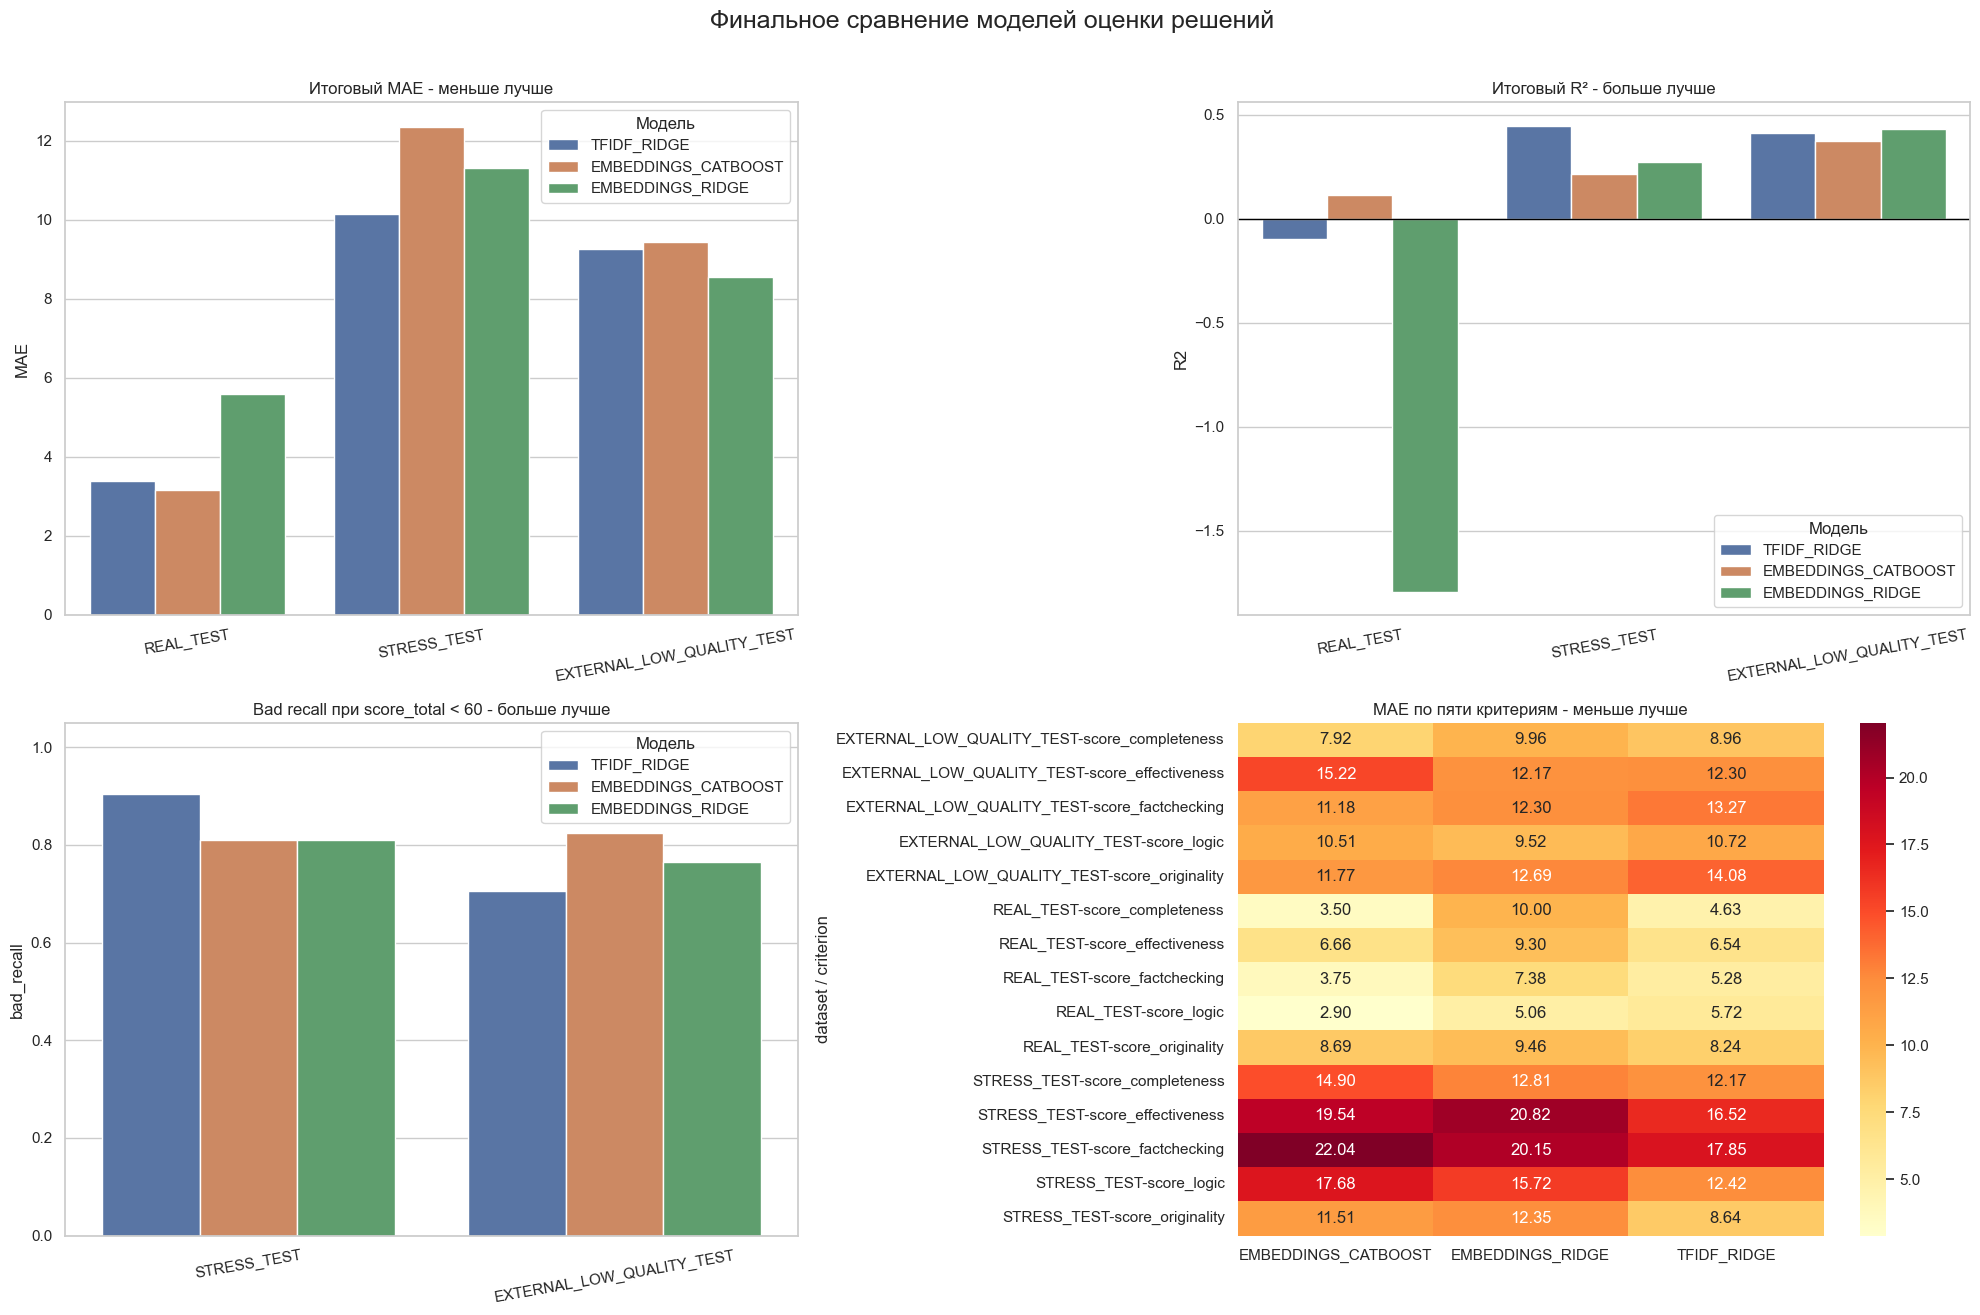

In [53]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(20, 13))

sns.barplot(data=final_total_metrics_df, x='dataset', y='MAE', hue='model', ax=axes[0, 0])
axes[0, 0].set_title('Итоговый MAE - меньше лучше')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=10)

sns.barplot(data=final_total_metrics_df, x='dataset', y='R2', hue='model', ax=axes[0, 1])
axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].set_title('Итоговый R² - больше лучше')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=10)

recall_plot_df = final_total_metrics_df.dropna(subset=['bad_recall'])
sns.barplot(data=recall_plot_df, x='dataset', y='bad_recall', hue='model', ax=axes[1, 0])
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].set_title('Bad recall при score_total < 60 - больше лучше')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=10)

criterion_heatmap = final_all_metrics_df.loc[
    final_all_metrics_df['score'].isin(Y_cols),
].pivot_table(index=['dataset', 'score'], columns='model', values='MAE')
sns.heatmap(criterion_heatmap, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_title('MAE по пяти критериям - меньше лучше')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('dataset / criterion')

for ax in axes.flat:
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title('Модель')
fig.suptitle('Финальное сравнение моделей оценки решений', fontsize=18, y=1.01)
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'final_model_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

## Результаты сравнения

## Итоговые выводы

- CatBoost показал лучший итоговый MAE на REAL_TEST: 3,1610.
- TF-IDF + Ridge лучше всего работает на STRESS_TEST: MAE 10,1512 и bad recall 0,9048.
- Ridge на embeddings дал лучший MAE на EXTERNAL_LOW_QUALITY_TEST: 8,5672.
- Единственной лучшей модели для всех трёх наборов нет: CatBoost точнее на обычных решениях, TF-IDF + Ridge устойчивее на стресс-наборе, а Ridge на embeddings лучше обобщается на внешней выборке. 

In [55]:
final_all_metrics_df.to_csv(ARTIFACTS_DIR / 'final_all_models_metrics.csv', index=False)
final_total_table.to_csv(ARTIFACTS_DIR / 'final_all_models_total_table.csv')
criterion_mae_table.to_csv(ARTIFACTS_DIR / 'final_all_models_criterion_mae.csv')
{
    'metrics': ARTIFACTS_DIR / 'final_all_models_metrics.csv',
    'total_table': ARTIFACTS_DIR / 'final_all_models_total_table.csv',
    'criterion_table': ARTIFACTS_DIR / 'final_all_models_criterion_mae.csv',
    'figure': ARTIFACTS_DIR / 'final_model_comparison.png',
}

{'metrics': WindowsPath('../artifacts/final_all_models_metrics.csv'),
 'total_table': WindowsPath('../artifacts/final_all_models_total_table.csv'),
 'criterion_table': WindowsPath('../artifacts/final_all_models_criterion_mae.csv'),
 'figure': WindowsPath('../artifacts/final_model_comparison.png'),
 'conclusions': WindowsPath('../artifacts/final_model_conclusions.md')}

## Общий вывод

CatBoost оказался самым точным на обычных тестовых решениях, но хуже перенёсся на слабые ответы, так что для нашей задачи он не подходит: нам важнее лучше распознавать весь спектр оценок, чем незаслуженно завышать оценки. TF-IDF + Ridge лучше распознаёт ошибки из стресс-набора, а Ridge на embeddings показал минимальный MAE на независимой внешней выборке. Разница между наборами показывает, что качество модели нельзя оценивать только по одному тесту.\
Нельзя не отметить, что оценивать фактчекинг с помощью таких моделей нельзя: без поиска информации в интернете оценка по этому критерию ничего не стоит, так как факты достаточно быстро меняются и в самом датасете не может быть отражено всех фактов обо всем, что известно в мире (это просто нелогично).